<a href="https://colab.research.google.com/github/theyugster/Intro_To_ML/blob/main/U4CSE24252(Support_Vector_Machine).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.svm import SVC
from sklearn import metrics
import seaborn as sns

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salihacur/diabetes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes


In [16]:
import os
print(os.listdir(path))

['diabetes.csv']


In [17]:
df = pd.read_csv(f"{path}/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
feature_cols = ["Pregnancies","Glucose","BloodPressure","Insulin","BMI","Age",
"DiabetesPedigreeFunction"]
x = df[feature_cols]
y = df.Outcome
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  Insulin   BMI  Age  \
0              6      148             72        0  33.6   50   
1              1       85             66        0  26.6   31   
2              8      183             64        0  23.3   32   
3              1       89             66       94  28.1   21   
4              0      137             40      168  43.1   33   
..           ...      ...            ...      ...   ...  ...   
763           10      101             76      180  32.9   63   
764            2      122             70        0  36.8   27   
765            5      121             72      112  26.2   30   
766            1      126             60        0  30.1   47   
767            1       93             70        0  30.4   23   

     DiabetesPedigreeFunction  
0                       0.627  
1                       0.351  
2                       0.672  
3                       0.167  
4                       2.288  
..                        ...  
763    

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(576, 7) (576,) (192, 7) (192,)


In [20]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [21]:
model = SVC(kernel="rbf",random_state = 0)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,y_pred))
print(y_pred)

Accuracy: 0.78125
[1 0 0 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0
 0 1 0 0 0 0 0]


In [22]:
from sklearn.metrics import classification_report

conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('SVC [ kernal - linear ]')
print('Confusion Matrix : \n', conf_mat)
Accuracy_score=metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score*100),'%')
print(classification_report(y_pred,y_test))

SVC [ kernal - linear ]
Confusion Matrix : 
 [[118  12]
 [ 30  32]]
Accuracy Score :  0.78125
Accuracy in Percentage :  78 %
              precision    recall  f1-score   support

           0       0.91      0.80      0.85       148
           1       0.52      0.73      0.60        44

    accuracy                           0.78       192
   macro avg       0.71      0.76      0.73       192
weighted avg       0.82      0.78      0.79       192



[Text(0.5, 1.0, 'SVC [linear]')]

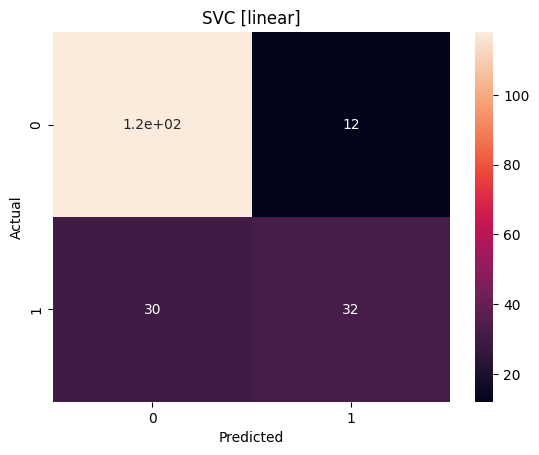

In [23]:


conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual'],
                     colnames=['Predicted'])
sns.heatmap(conf_mat, annot=True).set(title='SVC [linear]')

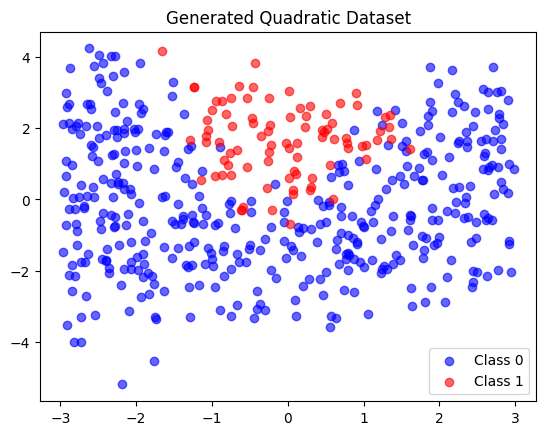

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.uniform(-3, 3, (500, 2))


y = (X[:, 1] > X[:, 0]**2).astype(int)

X[:, 1] += np.random.normal(0, 0.8, 500)

plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Class 0', alpha=0.6)
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1', alpha=0.6)
plt.title('Generated Quadratic Dataset')
plt.legend()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import metrics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

x_train_quad, x_test_quad, y_train_quad, y_test_quad = train_test_split(X, y, test_size=0.25, random_state=0)

In [26]:
sc_quad = StandardScaler()
x_train_quad = sc_quad.fit_transform(x_train_quad)
x_test_quad = sc_quad.transform(x_test_quad)

In [27]:
model_quad = SVC(kernel="rbf", random_state=0)
model_quad.fit(x_train_quad, y_train_quad)
y_pred_quad = model_quad.predict(x_test_quad)
print("Accuracy:", metrics.accuracy_score(y_test_quad, y_pred_quad))

Accuracy: 0.92


In [28]:
from sklearn.metrics import classification_report

conf_mat_quad = metrics.confusion_matrix(y_test_quad, y_pred_quad)
print('SVC [kernel - rbf]')
print('Confusion Matrix : \n', conf_mat_quad)
Accuracy_score_quad = metrics.accuracy_score(y_test_quad, y_pred_quad)
print('Accuracy Score : ', Accuracy_score_quad)
print('Accuracy in Percentage : ', int(Accuracy_score_quad * 100), '%')
print(classification_report(y_pred_quad, y_test_quad))

SVC [kernel - rbf]
Confusion Matrix : 
 [[98  2]
 [ 8 17]]
Accuracy Score :  0.92
Accuracy in Percentage :  92 %
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       106
           1       0.68      0.89      0.77        19

    accuracy                           0.92       125
   macro avg       0.83      0.91      0.86       125
weighted avg       0.93      0.92      0.92       125



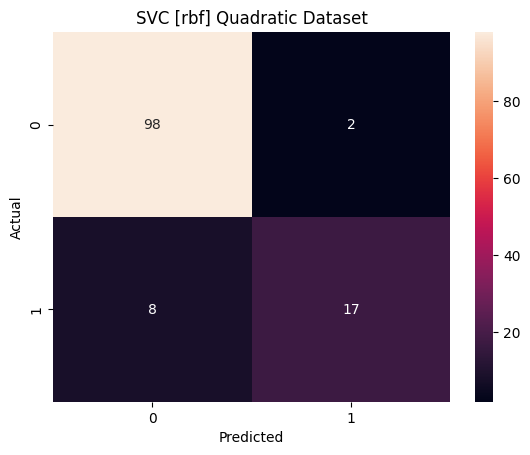

In [29]:
conf_mat_quad_df = pd.crosstab(y_test_quad, y_pred_quad, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_mat_quad_df, annot=True).set(title='SVC [rbf] Quadratic Dataset')
plt.show()

In [30]:


# Download latest version
path = kagglehub.dataset_download("kaggleprollc/spam-email-data-uci")

print("Path to dataset files:", path)

100%|██████████| 130k/130k [00:00<00:00, 38.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kaggleprollc/spam-email-data-uci/versions/1


In [31]:
print(os.listdir(path))

['spambase.DOCUMENTATION', 'spambase.data', 'spambase.names']


In [34]:
df = pd.read_csv(f'{path}/spambase.data')
df

,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278,1
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.000,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4596,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4597,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4598,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [35]:
X_spam = df.iloc[:, :-1]
y_spam = df.iloc[:, -1]

x_train_spam, x_test_spam, y_train_spam, y_test_spam = train_test_split(X_spam, y_spam, test_size=0.25, random_state=0)

In [36]:
sc_spam = StandardScaler()
x_train_spam = sc_spam.fit_transform(x_train_spam)
x_test_spam = sc_spam.transform(x_test_spam)

In [37]:
model_spam = SVC(kernel="rbf", random_state=0)
model_spam.fit(x_train_spam, y_train_spam)
y_pred_spam = model_spam.predict(x_test_spam)
print("Accuracy:", metrics.accuracy_score(y_test_spam, y_pred_spam))

Accuracy: 0.94


In [38]:
conf_mat_spam = metrics.confusion_matrix(y_test_spam, y_pred_spam)
print('SVC [kernel - rbf] for Spambase')
print('Confusion Matrix : \n', conf_mat_spam)
Accuracy_score_spam = metrics.accuracy_score(y_test_spam, y_pred_spam)
print('Accuracy Score : ', Accuracy_score_spam)
print('Accuracy in Percentage : ', int(Accuracy_score_spam * 100), '%')
print(classification_report(y_pred_spam, y_test_spam))

SVC [kernel - rbf] for Spambase
Confusion Matrix : 
 [[665  27]
 [ 42 416]]
Accuracy Score :  0.94
Accuracy in Percentage :  94 %
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       707
           1       0.91      0.94      0.92       443

    accuracy                           0.94      1150
   macro avg       0.93      0.94      0.94      1150
weighted avg       0.94      0.94      0.94      1150



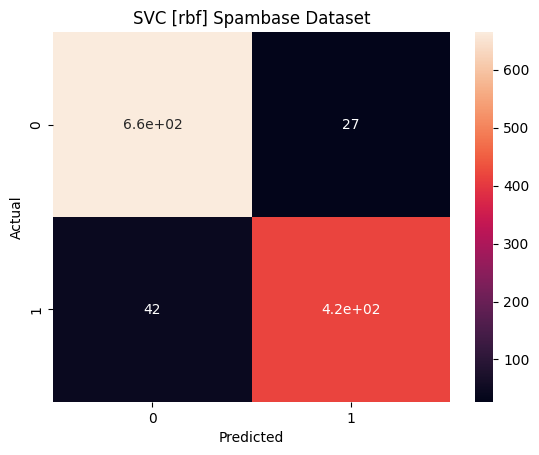

In [39]:
conf_mat_spam_df = pd.crosstab(y_test_spam, y_pred_spam, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(conf_mat_spam_df, annot=True).set(title='SVC [rbf] Spambase Dataset')
plt.show()